# Sap Flow and Transpiration

> Sap flow is the movement of water in roots, stems and branches of plants. Typically measured   in sapwood xylem, or the water-conducting tissue of the plant, sap flow provides information on water status and water use of plants. 

<table>
<tr><td>
<img src="https://ictinternational.com/wp-content/uploads/2023/03/HFD-Needles-1024x707.png" height="200" /> 
</td><td>
<img src="https://ictinternational.com/wp-content/uploads/2023/05/SFM1-installed-on-Rainforest-Species-scaled-jpg.webp" height="200"/>
</td></tr>
</table>

CROCUS (NEIU) has (six) sap flow meters installed on our campus. Detailed information about these meters can be found from ICT Interanational and other online sources. 

- https://ictinternational.com/
- https://labcontrol.com.br/wp-content/uploads/2018/03/SFM1-Manual-v5.pdf
- https://www.youtube.com/c/ICTinternational

SFM1 Sap Flow Meter
  Two thermisters are located on the 35 mm needles at a depth of 12.5 mm and 27.5 mm from the base of the cap and 7.5mm and 22.5 mm from the tip of the measurement needles.


## Thermodynamics

The change in energy ($U$) of a system is the heat ($Q$) added and work ($W$) done on the system. For an infintesimal change substance with heat capacity $C$:

$$
dU = dQ + dW = CdT
$$

### Heat Flow

Fourier's law of heat conduction through an area $A$ in a time interval $\Delta t$ is:
$$
\frac{Q}{\Delta t} = -k_t A \frac{dT}{dz}
$$
where $k_t$ is the thermal conductivity of the material. For a homogeneous isotopic material with specific heat $c$, $Q = $

Conduction of heat through an isotropic, homogenous solid with thermal
diffusivity $\alpha$

$$
\frac{\partial T}{\partial t} = \alpha\nabla^2 T
$$
Consider a uniform stream of sap moving in the vertical direction at a speed $w$. The heat contained in an infinestimal volume of sap with cross sectional area $A$ and height $dz=w dt$ is:
$$
Q_s = \rho_s c_s T A dz
$$
When the temperature is not uniform in $z$, during a time $dt = dz/w$ sap advection contributed to the heating or cooling the volume by an amount
$$
dQ_s = -\rho_s c_s T A dz + \rho_s c_s (T-dT) A dz = -\rho_s c_s A dT dz
$$
During a time interval $dz = w dt$:
$$
\frac{1}{A}\frac{dQ_s}{dt} = -w \rho_s c_s \frac{dT}{dt}
$$
Combining:
$$
\frac{\partial T}{\partial t} = \alpha\nabla^2 T - Aw...
$$


### Heat Ratio Method (HRM):
$$
V_h = \frac{\alpha}{x}\ln\left(\frac{\Delta T_1}{\Delta T_2}\right)
$$
where $x = 0.6$ cm is the spacing between the probes and the heater element, $\Delta T$ is the temperature increase
relative to the initial temperature, and $\alpha$ is the thermal diffusivity:
$$
\alpha = \frac{\kappa}{\rho c_p}
$$
where $\kappa$ is the thermal conductivity, $c_p$ is the specific heat, and $\rho$ is the density. $\alpha$ is assigned a nominal value of $2.5\times 10^{-3}{\rm cm}^{2}/{\rm s}$.

Unprocessed units:

- Needle Temperature (degC)
- Heat Pulse Velocity (cm/hr)

With additional information

- Corrected Sap Velocity (cm/hr): includes correctors for
   - Thermal diffusivity of the measured plant.
   - Wounding corrections

    $$
    V_c = b V_h + c V_h^2 + d V_h^3
    \tag{Eq.~5}
    $$
   
   - Corrections due to geometric deviations from the theoretical geometry of the Heat Ration Method. 

- Corrected Sap Flow (cm^3/hr):

$$
V_s = V_c \left(\frac{\rho_{d}}{\rho_s}\right)\left(\frac{c_d + f c_s}{c_s}\right)
\tag{Eq.~7}
$$
where $\rho_{d}$ is the basic dentity of wood (dry weight/green volume),
$\rho_s$ is the density of water (sap), 
$c_w=1200$ J/kg degC is the specific heat capacity of the wood matrix,
$c_s$ is the the specific heat capacity of sap, 
and 
$f is the water content of sapwood.

Moisture fraction
$$
f = \frac{m_g-m_d}{m_d} = \frac{m_w}{m_d}
$$
where $m_g$ is the green weight and $m_d$ is the oved dried weight.

The heat capacity of green wood is related to the heat capacity of dry wood by:
$$
C_{g} =  \frac{m_d}{m_d+m_w} C_d + \frac{m_w}{m_d+m_w} C_w 
$$


Heat Ratio Method (Marshall 1958):

### Correction for probe misalignment (Becker 1998):

## MET Variables driving sap flow
vapor pressure deficit (VPD): the difference in pressure exerted by water vapor in saturated air and the water vapor in the air being measured.

VPD = vp_sat *(1-RH/100)


## Load libraries

In [ ]:
# Standard library imports
# Third party imports
# Local imports

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import datetime as dt
from pytz import timezone

### Metadata for the six NEIU sap flow meters

In [ ]:
# move to .py file
# import sapflow_wd as md
md = [{'Serial Number': 'SX61NA0C', 'diameter': 69.1, 'Species': 'Quercus bicolor', 'lat': 41.97747, 'lon': -87.716519},
        {'Serial Number': 'SX61NA0X', 'diameter': 59.8, 'Species': 'Quercus bicolor', 'lat': 41.97742, 'lon': -87.716589},
        {'Serial Number': 'SX61NA09', 'diameter': 65.6, 'Species': 'Ulmus americana', 'lat': 41.97905, 'lon': -87.716171},
        {'Serial Number': 'SX61NA01', 'diameter': 50.9, 'Species': 'Acer saccharum',  'lat': 41.98138, 'lon': -87.7167416},
        {'Serial Number': 'SX61NA0J', 'diameter': 46.5, 'Species': 'Acer saccharum',  'lat': 41.98137, 'lon': -87.717400},
        {'Serial Number': 'SX61NA0N', 'diameter': 35.3, 'Species': 'Acer saccharum',  'lat': 41.98144, 'lon': -87.717564},
        ]

trees_df = pd.DataFrame(md)
print(trees_df)
print(trees_df.loc[0,'Serial Number'])

  Serial Number  diameter          Species       lat        lon
0      SX61NA0C      69.1  Quercus bicolor  41.97747 -87.716519
1      SX61NA0X      59.8  Quercus bicolor  41.97742 -87.716589
2      SX61NA09      65.6  Ulmus americana  41.97905 -87.716171
3      SX61NA01      50.9   Acer saccharum  41.98138 -87.716742
4      SX61NA0J      46.5   Acer saccharum  41.98137 -87.717400
5      SX61NA0N      35.3   Acer saccharum  41.98144 -87.717564
SX61NA0C


## Functions used in this script

In [4]:
# Returns the saturated vapor pressure in hPa for input temperatures in Celsius
def vp_sat(T):    # Arden Buck Equations (1981,1996):

    if (T > 0):
        Pc = 6.1121
        A = 18.678
        B = 234.5
        C = 257.14
    else:
        Pc = 6.1115
        A = 23.036
        B = 333.7
        C = 279.82

    vp_sat = Pc*math.exp( (A-T/B)*T/(C+T) )

    return vp_sat

vp_sat_vectorized = np.vectorize(vp_sat)

In [5]:
def wrangle_sapflow_data(df):

   # df.replace([np.inf, -np.inf], np.nan)  # get rid of NaN and -inf values
   # df.dropna(inplace=True)

    cst_timezone = timezone('US/Central')
    df.rename(columns={'Date ':'Date'}, inplace=True)
    df.rename(columns={'Time ':'Time'}, inplace=True)

    time_format = "%H:%M:%S"
    date_format = "%d/%m/%y"

    df['Datetime'] = df['Date'] + " " + df['Time']
#    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)        
#    df['Date'] = pd.to_datetime(df['Date'], format=date_format)       
    df['Time'] = pd.to_datetime(df['Time'],format=time_format,utc=False)    
    df['Datetime'] = pd.to_datetime(df['Datetime'], dayfirst=True,utc=False)
    df['Datetime'] = df['Datetime'].dt.tz_localize(cst_timezone)

    df['hod'] = df['Time'].dt.hour + df['Time'].dt.minute/60.  # floating point hour of day
    df['doy'] = df['Datetime'].dt.dayofyear

    return df

In [8]:
# Wrangling weather data
def wrangle_wx_data(wxd):
    wxd.replace([np.inf, -np.inf], np.nan)  # get rid of NaN and -inf values
    wxd.dropna(inplace=True)
    wxd['Date'] = pd.to_datetime(wxdata6['Date'],utc=False)
    wxd['Outdoor Temperature (°C)'] = 5*(wxd['Outdoor Temperature (°F)'] -32)/9
    # Saturated vapor pressure 
    wxd['Ps'] = vp_sat_vectorized(wxd['Outdoor Temperature (°C)'])
    wxd['VPD'] = wxd['Ps']*(1- wxd['Humidity (%)']/100)   # Vapor Pressure Defecit

    return wxd

Burgess et al. Tree PHysiology 21, 689-598.
Heat pulse velocity $V_h$

Sap velocity
Convert heat pulse velocity to sap flow velocity.
$$
V_s = V_c \left(\frac{\rho_{bw}}{\rho_s}\right)\left(\frac{c_w + r_w c_s}{c_s}\right)
\tag{Eq.~7}
$$

where $V_c$ is the corrected heat pulse velocity, $\rho_{bw}$ is the basic density of wood (dry weight/green volume), $\rho_s$ is the density of water. $c_w$ and $c_s$ are the speific heat capacities of the wood matrix and sap, $r_w$ is the ratio of water mass to wood mass in the sapwood.

In [9]:
def compute_sap_flow():  # This is not finished
    # Burgess et al. Tree PHysiology 21, 689-598.

    # https://labcontrol.com.br/wp-content/uploads/2018/03/SFM1-Manual-v5.pdf

    # Global constants
    c_w = 1200    # specific heat capacity of the wood matrix (J/kg degC)
    c_s = 4182    # specific heat capacity of sap (J/kg degC)
    rho_s = 1     # density of water (sap)

    # Constants unique to each tree
    
    dryweight=3.9 # Grams of dried wood
    wetweight=7.8; # Grams of wet wood

    watercontent=(wetweight-dryweight)/dryweight

    rho_b = 0.351     # Density of wood
    dbh=45.2

    #This is an empirical relationship between diameter and sapwood area for one species

    sapwoodarea= -77.454 + 13.507*dbh**0.886;

    # Sapwood area can be measured per tree by calculating the depth of the
    # sapwood from a core and estimating the area

    sapwoodarea = x  # cm^2

    # Wound correction of uncorrected sap velocity
    # Assume a wound diameter of 0.22 (which is a middle choice).  These
    # values from the ICT SFM1 manual

    bcorr = 1.7304
    ccorr = -0.0013
    dcorr= 0.0002

    velwound=bcorr*uncorrflux+ccorr*uncorrflux**2+dcorr*uncorrflux**3

    #Calculate corrected sap velocity
    
    corrV=(velwound*rho_b*(c_w+(watercontent*c_s)))/(rho_s*c_s);

    # Convert corrected sap velocity (cm hr-1) to sap flux (kg hr-1)
    flux = (corrV*sapwoodwarea)/1000
    return flux



matplotlib contourf(X,Y,Z) needs X and Y values in floats

## Read and Wrangle Data

In [10]:
# These files were split because the time step changed from 20 to 15 min)

filename = [None] *6
for i in range(0,6):
    filename[i] = "data/trees/" + trees_df.loc[i,'Serial Number'] + ".csv"

sf0a = pd.read_csv('data/trees/SX61NA0C.csv')  
sf0b = pd.read_csv('data/trees/SX61NA0C-b.csv')  

sf3 = pd.read_csv(filename[3], skiprows=18)  
sf4 = pd.read_csv(filename[4], skiprows=18)  
sf5 = pd.read_csv(filename[5], skiprows=18)  

sf0a = wrangle_sapflow_data(sf0a)
sf0b = wrangle_sapflow_data(sf0b)
sf3 = wrangle_sapflow_data(sf3)
#sf4 = wrangle_sapflow_data(sf4)
#sf5 = wrangle_sapflow_data(sf5)

#print(sf0a.dtypes)
print(sf3.head(n=3))
print('sensor=',filename[3])
display(sf3)

         Date                Time  Uncorrected Out (cm/hr)  \
0  19/07/2024 1900-01-01 13:10:04                    1.824   
1  19/07/2024 1900-01-01 13:16:31                    4.301   
2  19/07/2024 1900-01-01 13:40:00                    2.467   

   Uncorrected In (cm/hr)  Corrected Out (cm/hr)  Corrected In (cm/hr)  \
0                  32.832                  2.028                36.514   
1                  27.976                  4.784                31.113   
2                  34.599                  2.743                38.479   

   Sap Flow Out (kg/hr)  Sap Flow In (kg/hr)  Internal Battery Voltage (V)  \
0                 0.020                0.365                          4.14   
1                 0.048                0.311                          4.15   
2                 0.027                0.385                          4.11   

   Battery Charge Current (mA)  Internal Battery Temperature (°C)  \
0                        200.0                              25.00   
1  

,Date,Time,Uncorrected Out (cm/hr),Uncorrected In (cm/hr),Corrected Out (cm/hr),Corrected In (cm/hr),Sap Flow Out (kg/hr),Sap Flow In (kg/hr),Internal Battery Voltage (V),Battery Charge Current (mA),Internal Battery Temperature (°C),External Power Supply Present,External Power Supply Voltage (V),External Power Supply Current (mA),Diagnostic Message,Unnamed: 15,Datetime,hod,doy
0,19/07/2024,1900-01-01 13:10:04,1.824,32.832,2.028,36.514,0.020,0.365,4.14,200.0,25.00,present,USB,USB,ok,NaN,2024-07-19 13:10:04-05:00,13.166667,201
1,19/07/2024,1900-01-01 13:16:31,4.301,27.976,4.784,31.113,0.048,0.311,4.15,200.0,27.72,present,USB,USB,ok,NaN,2024-07-19 13:16:31-05:00,13.266667,201
2,19/07/2024,1900-01-01 13:40:00,2.467,34.599,2.743,38.479,0.027,0.385,4.11,15.0,27.96,not_present,0.00,0.00,ok,NaN,2024-07-19 13:40:00-05:00,13.666667,201
3,19/07/2024,1900-01-01 14:00:00,2.423,34.217,2.694,38.055,0.027,0.381,4.11,15.0,25.57,not_present,0.00,0.00,ok,NaN,2024-07-19 14:00:00-05:00,14.000000,201
4,19/07/2024,1900-01-01 14:20:00,2.318,33.915,2.578,37.719,0.026,0.377,4.11,15.0,25.22,not_present,0.00,0.00,ok,NaN,2024-07-19 14:20:00-05:00,14.333333,201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,22/07/2024,1900-01-01 07:40:00,NaN,NaN,NaN,NaN,NaN,NaN,3.61,15.0,27.41,not_present,0.00,0.00,skipped: low power.,NaN,2024-07-22 07:40:00-05:00,7.666667,204
201,22/07/2024,1900-01-01 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,3.60,15.0,27.41,not_present,0.00,0.00,skipped: low power.,NaN,2024-07-22 08:00:00-05:00,8.000000,204
202,22/07/2024,1900-01-01 08:20:00,NaN,NaN,NaN,NaN,NaN,NaN,3.60,15.0,27.41,not_present,0.00,0.00,skipped: low power.,NaN,2024-07-22 08:20:00-05:00,8.333333,204
203,22/07/2024,1900-01-01 08:40:00,NaN,NaN,NaN,NaN,NaN,NaN,3.60,15.0,27.41,not_present,0.00,0.00,skipped: low power.,NaN,2024-07-22 08:40:00-05:00,8.666667,204


matplotlib contourf(X,Y,Z, [levels]) needs X and Y values in floats

In [11]:
dfMesh1 = pd.pivot_table(sf0a,
                        index='hod',         # row level grouping
                        columns='doy',       # columns level grouping
                        values='Sap Flow Out (kg/hr)',
                        dropna=True)


dfMesh2 = pd.pivot_table(sf0b,
                        index='hod',         # row level grouping
                        columns='doy',       # columns level grouping
                        values='Sap Flow Out (kg/hr)',
                        dropna=True)
#print(dfMesh.shape)
#print(dfMesh)

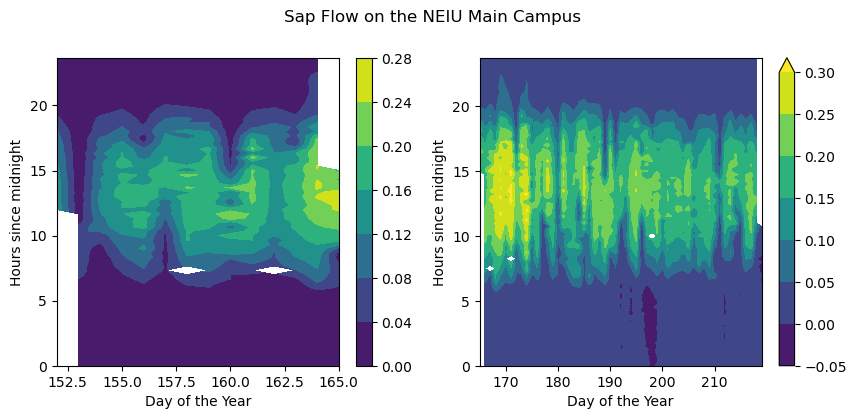

In [12]:
X = dfMesh1.columns.values
Y = dfMesh1.index.values
Z = dfMesh1.values

# Limites 0 to 1440
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10, 4))#, constrained_layout=True)

cs1 = ax1.contourf(X,Y,Z) 
cs2 = ax2.contourf(dfMesh2.columns.values,dfMesh2.index.values,dfMesh2.values,extend="max")
ax1.set_xlabel('Day of the Year')
ax1.set_ylabel('Hours since midnight')
ax2.set_xlabel('Day of the Year')
ax2.set_ylabel('Hours since midnight')
fig.suptitle('Sap Flow on the NEIU Main Campus',y=1)

plt.colorbar(cs1)
plt.colorbar(cs2)

plt.savefig('sapflow.png')

plt.show()

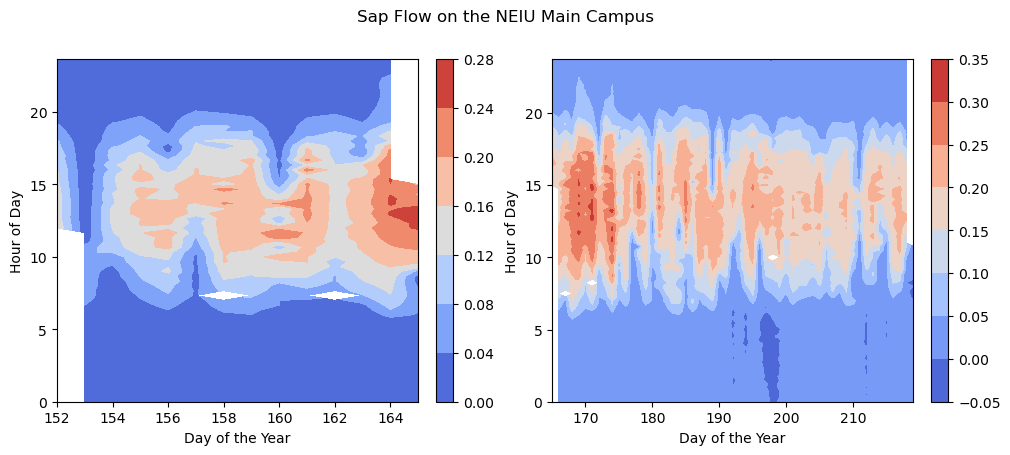

In [13]:

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10, 4), constrained_layout=True)
cs1 = ax1.contourf(X, Y, Z, cmap='coolwarm')
cs2 = ax2.contourf(dfMesh2.columns.values,dfMesh2.index.values,dfMesh2.values, cmap='coolwarm')

plt.colorbar(cs1)
plt.colorbar(cs2)

ax1.set_xlabel('Day of the Year')
ax1.set_ylabel('Hour of Day')
ax2.set_xlabel('Day of the Year')
ax2.set_ylabel('Hour of Day')

fig.suptitle('Sap Flow on the NEIU Main Campus',y=1.1)
plt.savefig('sapflow2.png')
plt.show()

In [14]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

wxdata6 = pd.read_csv("https://physics.neiu.edu/~anderson/research/data/wx/monthly/ambient-weather-20240601-20240630.csv")
wxdata7 = pd.read_csv("https://physics.neiu.edu/~anderson/research/data/wx/monthly/ambient-weather-20240701-20240731.csv")

wxdata6 = wrangle_wx_data(wxdata6)
wxdata7 = wrangle_wx_data(wxdata7)

In [15]:
import pytz
Ndays = 7
solar_day = dt.timedelta(days=1)
one_week = dt.timedelta(days=7)
timezone = pytz.timezone('US/Central')
start_dt = dt.datetime(2024,6,1,tzinfo=pytz.timezone('America/Chicago'))
#start_dt = dt.datetime(2024,6,1,tzinfo=dt.timezone.utc)
end_dt = start_dt + Ndays*solar_day

# subset the data to Ndays
mask = (wxdata6['Date'] > start_dt) & (wxdata6['Date'] <= end_dt)
wd = wxdata6.loc[mask]

#wd['VPD'] = get_vp_sat(tf_to_tc(wd['Outdoor Temperature (°F)']))*(1- wd['Humidity (%)']/100)
 
print(wd.dtypes)
wd.head(n=2)

Date                                      datetime64[ns, UTC-05:00]
Simple Date                                                  object
Outdoor Temperature (°F)                                    float64
Feels Like (°F)                                             float64
Dew Point (°F)                                              float64
Wind Speed (mph)                                            float64
Wind Gust (mph)                                             float64
Max Daily Gust (mph)                                        float64
Wind Direction (°)                                            int64
Hourly Rain (in/hr)                                         float64
Event Rain (in)                                             float64
Daily Rain (in)                                             float64
Weekly Rain (in)                                            float64
Monthly Rain (in)                                           float64
Yearly Rain (in)                                

,Date,Simple Date,Outdoor Temperature (°F),Feels Like (°F),Dew Point (°F),Wind Speed (mph),Wind Gust (mph),Max Daily Gust (mph),Wind Direction (°),Hourly Rain (in/hr),...,Avg Wind Speed (10 mins) (mph),Sensor 1 Feels Like (°F),Sensor 1 Dew Point (°F),Sensor 2 Feels Like (°F),Sensor 2 Dew Point (°F),Indoor Feels Like (°F),Indoor Dew Point (°F),Outdoor Temperature (°C),Ps,VPD
6600,2024-06-08 00:50:00-05:00,2024-06-08 00:50:00,64.2,64.2,52.2,1.1,2.0,4.3,221,0.0,...,1.6,70.0,50.8,69.8,50.6,70.3,52.0,17.888889,20.495272,7.173345
6601,2024-06-08 00:45:00-05:00,2024-06-08 00:45:00,64.4,64.4,52.0,1.8,2.5,4.3,199,0.0,...,1.3,69.8,50.6,69.8,50.6,70.1,51.9,18.000000,20.639086,7.430071


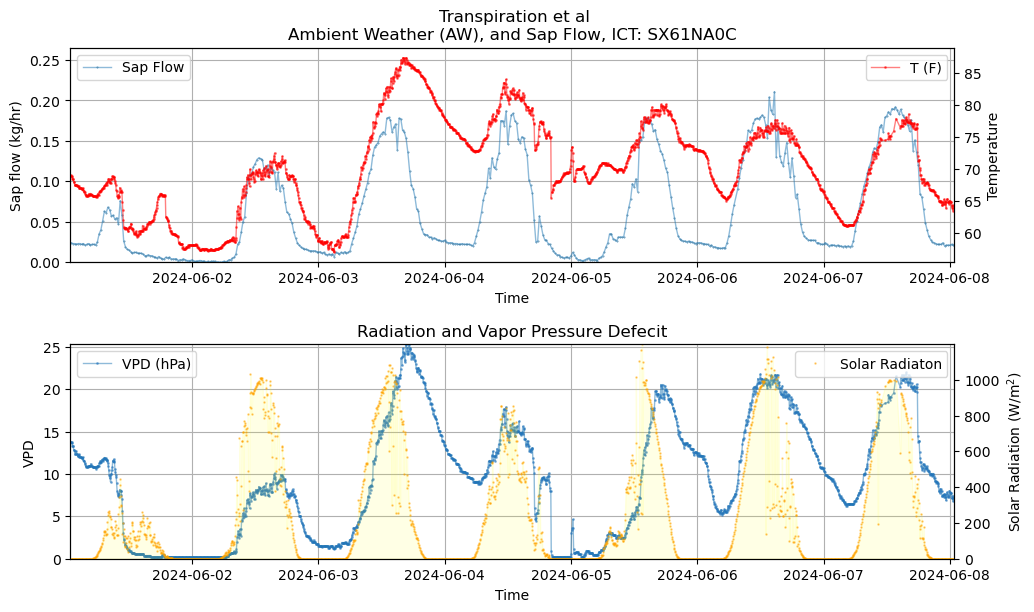

In [16]:
max_sf = sf0a['Sap Flow Out (kg/hr)'].max()
max_vpd = wd['VPD'].max()
max_rad = wd['Solar Radiation (W/m^2)'].max()


fig = plt.figure(figsize=(10,6),num="window name")
fig.suptitle('Transpiration et al')

ax1a = fig.add_subplot(2, #nrows
                        1, #ncols
                        1) # index position
ax2a = fig.add_subplot(2, #nrows
                        1, #ncols
                        2) # index position
ax1b = ax1a.twinx()
ax2b = ax2a.twinx()
ax1a.axis([start_dt,end_dt,0,max_sf])
ax2a.axis([start_dt,end_dt,0,max_vpd])
ax2b.axis([start_dt,end_dt,0,max_rad])
fig.tight_layout(h_pad=4) # h_pad=2
#fig.subplots_adjust(left=0.1,right=0.9) # 

ax1a.set_title('Ambient Weather (AW), and Sap Flow, ICT: ' + trees_df.loc[0,'Serial Number'])
ax1a.set_xlabel('Time')
ax1a.set_ylabel('Sap flow (kg/hr)')
ax1b.set_ylabel('Temperature')

ax2a.set_title('Radiation and Vapor Pressure Defecit')
ax2a.set_xlabel('Time')
ax2a.set_ylabel('VPD')
ax2b.set_ylabel('Solar Radiation (W/m${}^2$)')

ax1a.grid(True)
ax2a.grid(True)
#major_angle_ticks = np.arange(0,360,90)
#ax2a.set_yticks(major_angle_ticks)

ax1a.plot(sf0a['Datetime'],
            sf0a['Sap Flow Out (kg/hr)'],
           label='Sap Flow',
           linestyle='solid',
           linewidth=1,
           marker='*',
           markersize=1,
           mfc='darkorange',
           alpha=0.5)

ax1b.plot(wd['Date'],
           wd['Outdoor Temperature (°F)'],
           label='T (F)',
           linestyle='solid',
           color='red',
           linewidth=1,
           marker='o',
           markersize=1,
           mfc='red',
           alpha=0.5)

ax2a.plot(wd['Date'],
           wd['VPD'],
           label='VPD (hPa)',
           linestyle='solid',
           linewidth=1,
           marker='o',
           markersize=1,
           mfc='royalblue',
           alpha=0.5)

ax2b.fill_between(wd['Date'], wd['Solar Radiation (W/m^2)'], color='yellow', alpha=.1)
ax2b.plot(wd['Date'],
           wd['Solar Radiation (W/m^2)'],
           label='Solar Radiaton',
           linestyle='none',
           linewidth=0.5,
           markersize=0.75,
           marker='o',
           color='orange',
           mfc='darkorange',
           alpha=0.5)

ax1a.legend(loc='upper left')
ax1b.legend(loc='upper right')
ax2a.legend(loc='upper left')
ax2b.legend(loc='upper right')
plt.savefig('sap_timeseries.png')
plt.show()

# References

1. An improved heat pulse method to measure low and reverse rates of sap flow in woody plants